In [1]:
%load_ext autoreload
%autoreload 2

import sys; sys.path.append("../")

import torch
from models.unet import UNet
from diffusion.diff import DiffusionTrainer

import omegaconf 
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms

In [2]:
conf = omegaconf.OmegaConf.load("../config/diffusion.yaml")
model = DiffusionTrainer(UNet(conf), conf)

with open("../../checkpoints/diffusion.pth", "rb") as f:
    model.load_state_dict(torch.load(f, map_location="cuda"))

transform = transforms.Compose([transforms.ToTensor()])
valset = torchvision.datasets.CIFAR10(root='~/data/', train=False, download=True, transform=transform)
classes = valset.classes # ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
classes

/lfs/mercury1/0/eshaanb/lean-ebm/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [37]:
def plot_results (generated_images, random_conditions):
    # Setup the plot
    fig, axes = plt.subplots(1, generated_images.size(0), figsize=(generated_images.size(0)*2, 2.5))
    fig.suptitle("Conditional Diffusion Generation (CIFAR-10)", fontsize=16)

    for i in range(generated_images.size(0)):
        # PyTorch images are (C, H, W). Matplotlib expects (H, W, C).
        img_np = generated_images[i].permute(1, 2, 0).numpy()
        
        # Get the human-readable class name
        label_name = classes[random_conditions[i].item()]
        
        axes[i].imshow(img_np)
        axes[i].set_title(label_name)
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()

Generating 10 samples... This might take a minute.


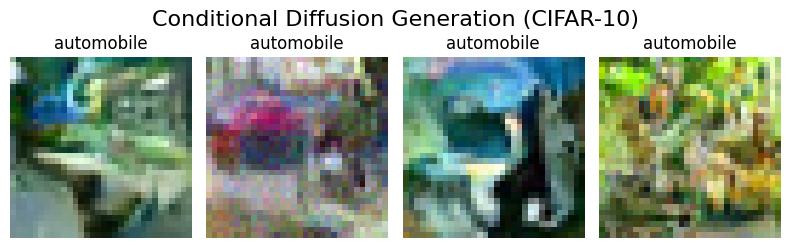

In [48]:
num_samples = 4
device = "cuda"
sigma_t = 0.1

# set one condition
#random_conditions = torch.randint(0, 10, (num_samples,), device=device)
one_condition = torch.full((num_samples,), 1).to(device)

print("Generating 10 samples... This might take a minute.")
x_init = torch.randn(num_samples, 3, 32, 32, device=device)
with torch.no_grad():
    # Pass our random conditions into the sample function
    generated_images = model.sample(
        x_init=x_init, 
        sigma_t=sigma_t, 
        num_steps=100, 
        condition=one_condition
    )
generated_images = (generated_images.cpu() + 1.0) / 2.0
generated_images = torch.clamp(generated_images, 0.0, 1.0)
plot_results(generated_images, one_condition)

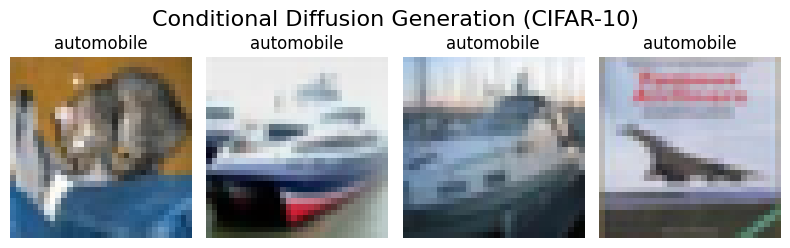

In [43]:
plot_results(torch.from_numpy(valset.data[0:4]).permute(0,3,1,2), one_condition)